Utilzzando il dataset Iris, replicare l'esercitazione pratica.
    - Effettuare lo split dei dati con test_set=0.2 e shuffle=True e stratify=y
    - Effettuare la standarizzazione di train e test set
    - Allenare un regressore logistico per predire le label sul test set
    - Calcolare poi accuracy, precision, recall, f1, auc
    -  Subplottare le ROC Curve di ogni label
    (0=setosa, 1=virginica, 2=versicolor)

In [53]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, recall_score, roc_auc_score,roc_curve, precision_score, balanced_accuracy_score, auc
import pandas as pd

In [2]:
data=load_iris()
X=data.data
y=data.target

df=pd.DataFrame(X,columns=data.feature_names)
df["target"]=y
display(df)
#df["target"].value_counts()  #ho anche valori nulli
df.groupby("target").count()  #conta i valori non nulli per colonna

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
target,,,,
0,50,50,50,50
1,50,50,50,50
2,50,50,50,50


- Effettuare lo split dei dati con test_set=0.2 e shuffle=True e stratify=y

In [3]:
X_train, X_test, y_train, y_test=train_test_split(X,y,shuffle=True, stratify=y,test_size=0.2,random_state=42)

    - Effettuare la standarizzazione di train e test set

In [4]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

    - Allenare un regressore logistico per predire le label ssul test set

In [5]:
model=LogisticRegression(max_iter=1_000) 
model.fit(X_train_scaled,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [44]:
y_pred=model.predict(X_test_scaled)
y_prob=model.predict_proba(X_test_scaled)#[:,1]  #[:,1]=secondo colonna, ha la probabilità dei positivi

    - Calcolare poi accuracy, precision, recall, f1, auc

In [45]:
accuracy=accuracy_score(y_test, y_pred)
balanced_accuracy=balanced_accuracy_score(y_test, y_pred)
precision=precision_score(y_test,y_pred,average ="macro") #va bene anche macro (al posto di weighted) perche le 3 classi hanno tutte 50 rilevazioni, pertanto non ho una classe che domina le altre
precision_classe=precision_score(y_test,y_pred,average =None)
recall=recall_score(y_test,y_pred,average="macro")
recall_classe=recall_score(y_test,y_pred,average=None)
f1=f1_score(y_test,y_pred,average="macro")
auc_micro = roc_auc_score(y_test, y_prob, multi_class='ovr', average='micro')
auc_macro = roc_auc_score(y_test, y_prob, multi_class='ovr', average='macro')
auc_weighted = roc_auc_score(y_test, y_prob, multi_class='ovr', average='weighted')

In [48]:
print(f"Accuracy: {accuracy*100:.2f}")
print(f"Balance Accuracy: {balanced_accuracy*100:.2f}%")
print(f"Precision: {precision*100:.2f}")
print(f"Precision classe: {precision_classe*100}")
print(f"Recall: {recall*100:.2f}")
print(f"Recall classe: {recall_classe*100}")
print(f"F1: {f1*100:.2f}")
print(f"AUC OvR (micro):\t{auc_micro:.3f}")
print(f"AUC OvR (macro):\t{auc_macro:.3f}")
print(f"AUC OvR (weighted):\t{auc_weighted:.3f}")

Accuracy: 93.33
Balance Accuracy: 93.33%
Precision: 93.33
Precision classe: [100.  90.  90.]
Recall: 93.33
Recall classe: [100.  90.  90.]
F1: 93.33
AUC OvR (micro):	0.998
AUC OvR (macro):	0.997
AUC OvR (weighted):	0.997


ACCURACY ALTA (93.33%): il modello classifica correttamente il 93.33% delle osservazioni.
L'accuracy alta indica una buona performance complessiva del modello (confermata anche delle metriche che indico di seguito)

PRECISION ALTA (93.33%): il 93% delle predizioni sono corrette, il modello ha una buona capacità di evitare falsi positivi, cioè raramente assegna una classe in modo errato
Precision più alta sull'etichetta "setosa" (1) leggermente inferiore per le altre "versicolor" (2) e "virginica" (3)
Il modello mostra una buone precisione complessiva, indicando che le predizioni sono generalmente affidabili. 
Le metriche per classe evidenziano la classe "setosa" completamente affidabile con il 100% delle predizioni positive corrette, le altre leggermente inferiori 90%

RECALL ALTO (93.33%): il modello riesce a identificare correttamente il 93.33% dei vari casi di ciascuna classe (in media), cioè su 100 fiori di una classe ne trova circa 93 correttamente
Le metriche per classe evidenziano la classe "setosa" completamente affidabile 

Quando recall e precision sono simili vuole dire che il modello ha errori distribuiti tra positivi e negativi

F1 SCORE ALTO (93.33%)

Il modello NON sta facendo falsi positivi -> precisione alta
Il modlelo NON sta perdendo troppi veri -> recall alta
F1 SCORE alto 93.33% conferma un buon equilibrio tra precision e recall, indicando che il modello è in grado sia di identificare correttamente le classi sia di limitare gli errori, senza evidenti sbilanciamenti tra falsi positivi e falsi negativi

AUC OvR (micro):	0.998
AUC OvR (macro):	0.997
AUC OvR (weighted):	0.997
Il modello ha una capacità quasi perfetta di separare le classi, ma commette comunque errori nella classificazione finale (accuracy=93%), ogni tanto decide male.


    -  Subplottare le ROC Curve di ogni label
    (0=setosa, 1=virginica, 2=versicolor)

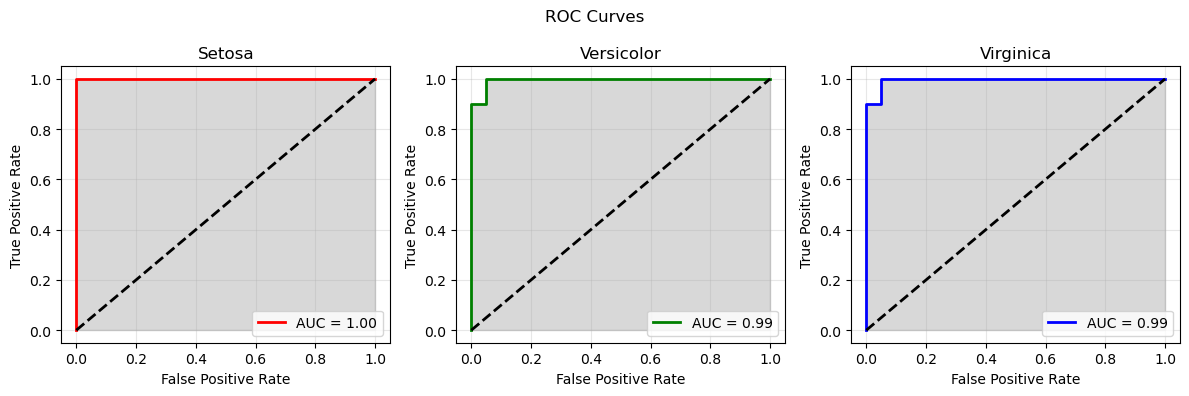

In [52]:
from sklearn.preprocessing import label_binarize
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
colors = ['red', 'green', 'blue']

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for i in range(y_test_bin.shape[1]):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)

    ax = axes[i]
    ax.plot(fpr, tpr, color=colors[i], lw=2, label=f'AUC = {roc_auc:.2f}')
    ax.fill_between(fpr, tpr, alpha=0.3, color='gray')
    ax.plot([0, 1], [0, 1], 'k--', lw=2)
    ax.set_xlim([-0.05, 1.05])
    ax.set_ylim([-0.05, 1.05])
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(data.target_names[i].capitalize())
    ax.legend(loc="lower right")
    ax.grid(True, alpha=0.3)

plt.suptitle("ROC Curves")
plt.tight_layout()
plt.show()